In [1]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
import time

In [2]:
df = pd.read_parquet('../Data/features_europe_energy.parquet', engine='fastparquet')



## Naive Baseline

In [3]:
split_date = '2025-05-01'

train = df[df['date'] < split_date].copy()
test = df[df['date'] >= split_date].copy()

print(f"Training: {train['date'].min()} - {train['date'].max()} (rows: {len(train)})")
print(f"Test: {test['date'].min()} - {test['date'].max()} (rows: {len(test)})")

y_test = test['price']

y_pred = test['price_lag_24h']

y_pred_naive = y_pred.fillna(train['price'].mean())

def print_metrics(y_true, y_pred, model_name="Model"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\n{model_name}")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R2: {r2:.4f}")

print_metrics(y_test, y_pred_naive, "Baseline")

Training: 2024-01-07 23:00:00+00:00 - 2025-04-30 23:00:00+00:00 (rows: 264430)
Test: 2025-05-01 00:00:00+00:00 - 2025-06-29 22:00:00+00:00 (rows: 33097)

Baseline
MAE: 24.88
RMSE: 38.71
R2: 0.5074


## Linear Regression

In [4]:
X_train = train.drop(columns=['price', 'date'])
y_train = train['price']

X_test = test.drop(columns=['price', 'date'])
y_test = test['price']

cat_features = ['country']
num_features = [col for col in X_train.columns if col not in cat_features]

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ])

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

start_time = time.time()
lr_pipeline.fit(X_train, y_train)

y_pred_lr = lr_pipeline.predict(X_test)

end_time = time.time()
print_metrics(y_test, y_pred_lr, "Linear Regression")
print(f"Czas wykonania: {end_time - start_time:.4f} sekundy")


Linear Regression
MAE: 21.66
RMSE: 30.47
R2: 0.6948
Czas wykonania: 0.9018 sekundy


In [5]:
test_res = test.copy()
test_res['pred'] = y_pred_lr

def plot_results(df, kraj='Poland', start='2025-05-01', end='2025-05-07', model_name='Regression'):

    fig, ax = plt.subplots(1, 2, figsize=(15, 6))

    sample = df.sample(5000, random_state=42) if len(df) > 5000 else df

    sns.scatterplot(data=sample, x='price', y='pred', alpha=0.4, color='royalblue', ax=ax[0])

    min_p = min(sample['price'].min(), sample['pred'].min())
    max_p = max(sample['price'].max(), sample['pred'].max())
    ax[0].plot([min_p, max_p], [min_p, max_p], color='red', linestyle='--', label='Ideały')

    ax[0].set_title('Prediction vs. Reality')
    ax[0].set_xlabel('Real price [€/MWh]')
    ax[0].set_ylabel('Estimated price [€/MWh]')
    ax[0].legend()
    ax[0].grid(alpha=0.3)

    mask = (df['country'] == kraj) & (df['date'] >= start) & (df['date'] <= end)
    df_kraj = df[mask]

    ax[1].plot(df_kraj['date'], df_kraj['price'], label='Real', color='black')

    ax[1].plot(df_kraj['date'], df_kraj['pred'], label=f'Model ({model_name})', color='orange', linestyle='--')

    ax[1].set_title(f'Price progression - {kraj}')
    ax[1].set_xlabel('Date')
    ax[1].set_ylabel('Price [€/MWh]')
    ax[1].legend()
    ax[1].grid(alpha=0.3)
    ax[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()

    safe_filename = model_name.lower().replace(' ', '_')
    plt.savefig(f'../Images/{safe_filename}_results.png')

    plt.show()

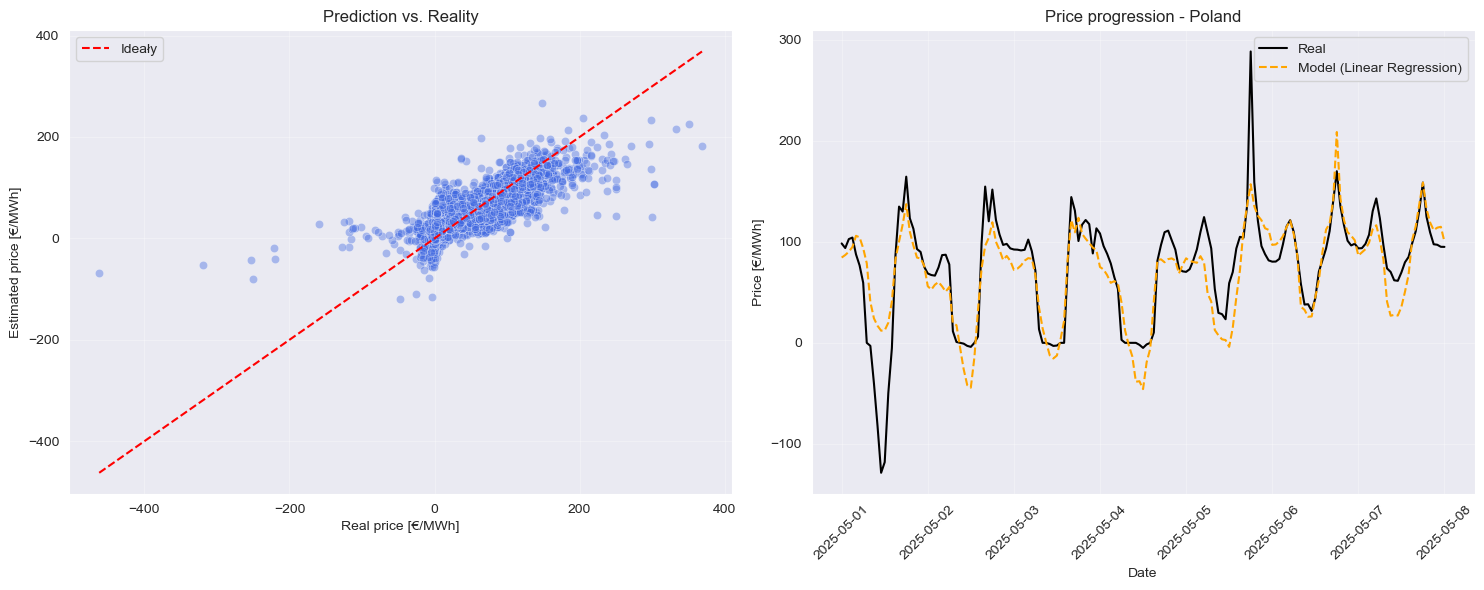

In [6]:
plot_results(test_res, kraj='Poland', start='2025-05-01', end='2025-05-08', model_name='Linear Regression' )

## Random forest
*Note: A limit on the tree depth (`max_depth=15`) and the number of estimators (`n_estimators=50`) was applied to prevent overfitting and speed up calculations on large datasets.*

In [7]:
start_time = time.time()

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=200,
        max_depth=25,
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)

time_minutes = (time.time() - start_time)
print(f"\nTrening zajął: {time_minutes:.2f}s")

print_metrics(y_test, y_pred_rf, "Model 2: Random Forest")

test_res['pred'] = y_pred_rf



Trening zajął: 155.53s

Model 2: Random Forest
MAE: 18.71
RMSE: 26.85
R2: 0.7629


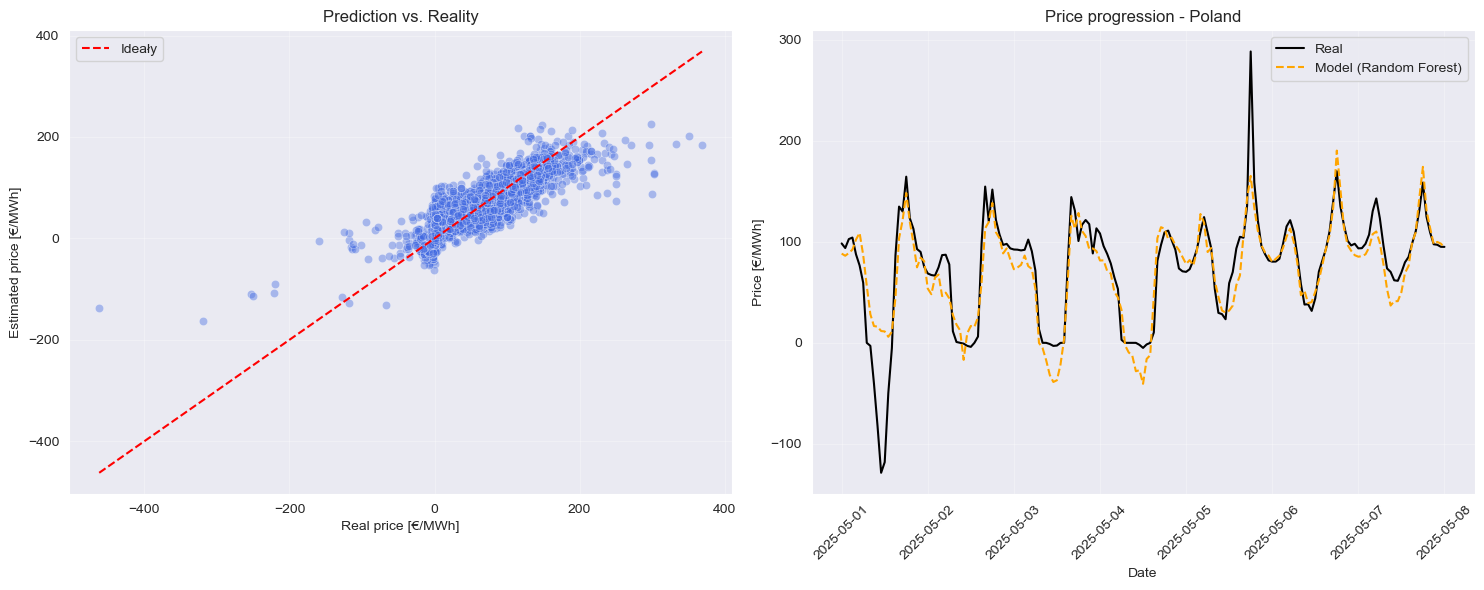

In [8]:
plot_results(test_res, kraj='Poland', start='2025-05-01', end='2025-05-08', model_name='Random Forest')